# 05 - GIN (Graph Isomorphism Network) & the expressivity ceiling

So far we've asked "does it work?" Now: **how powerful *can* a message-passing GNN be?**
The surprising answer (Xu et al., 2019; Morris et al., 2019): a standard MPNN (Message Passing Neural Network) is **at
most as powerful as the 1-dimensional Weisfeiler-Lehman (1-WL) graph isomorphism test**.
If 1-WL can't tell two graphs apart, *no* standard GNN can either.

**GIN** (Graph Isomorphism Network) is the architecture that actually *reaches* that
ceiling, by using **sum** aggregation (plus a Multi-Layer Perceptron) instead of mean or max. The update rule is:

$$ h_i' = \text{MLP}\Big( (1+\epsilon)\,h_i + \sum_{j\in N(i)} h_j \Big) $$

Sum is the key: it's an *injective* multiset function. Mean and max are not - and they
throw away information, as we'll see.

In [1]:
import os, sys, warnings, time
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(".."))   # make utils/ importable from notebooks/

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
pd.set_option("display.precision", 3)
torch.manual_seed(0); np.random.seed(0)

from utils import graphs as G     # synthetic graph generators (known ground truth)
from utils import models as M     # the model zoo (MLP, GCN, SAGE, GAT, GIN, GPS, ...)
from utils import training as T    # train/eval loops + metrics
from utils import plotting as P    # graph drawing, curves, comparisons


## The 1-WL ceiling: two graphs no MPNN can separate

Two graphs on 6 nodes, every node degree 2: **two triangles** vs **one 6-cycle**. They
are *not* isomorphic - but 1-WL assigns them identical colour histograms, so every
standard GNN produces identical graph embeddings. NetworkX's WL hash confirms it.

In [2]:
import networkx as nx
two_triangles = nx.Graph([(0,1),(1,2),(0,2),(3,4),(4,5),(3,5)])
six_cycle     = nx.cycle_graph(6)
h1 = nx.weisfeiler_lehman_graph_hash(two_triangles)
h2 = nx.weisfeiler_lehman_graph_hash(six_cycle)
print("WL hash, two triangles:", h1)
print("WL hash, 6-cycle      :", h2)
print("identical ->", h1 == h2, " -> no standard MPNN can distinguish them.")
print("(Telling these apart needs higher-order / subgraph GNNs - see the takeaway.)")

WL hash, two triangles: 6de89950f00660d47a6a47b68a218b4c
WL hash, 6-cycle      : 6de89950f00660d47a6a47b68a218b4c
identical -> True  -> no standard MPNN can distinguish them.
(Telling these apart needs higher-order / subgraph GNNs - see the takeaway.)


## Where GIN *beats* mean/GCN: reading degree

A case 1-WL **can** separate but **mean-aggregation throws away**: graphs that differ in
**density** (node degrees), with **constant node features**. With all-ones features the
mean of any neighbourhood is 1 - so a mean GNN is blind to degree. **Sum** encodes the
neighbour *count*, so GIN reads the difference and classifies; mean-GCN can't.

Class = denser vs sparser graph (a degree/density difference). Constant node features mean the signal is purely structural - sum-aggregation reads it, mean-aggregation cannot. 



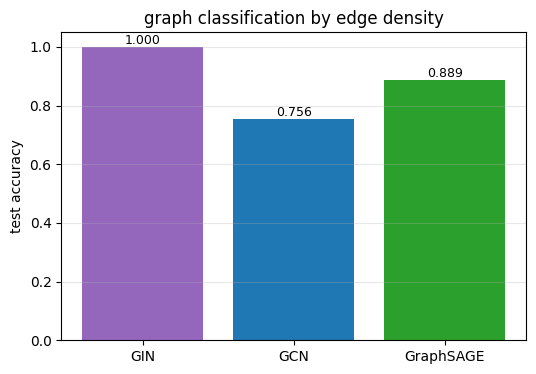

In [3]:
graphs, gt = G.make_expressivity_graphs(n_graphs=600, seed=0)
loaders = T.make_graph_loaders(graphs, batch_size=32, seed=0)
print(gt.description, "\n")

results = {}
for name, conv, pool in [("GIN", "gin", "add"), ("GCN", "gcn", "mean"), ("GraphSAGE", "sage", "mean")]:
    T.set_seed(0)
    m = M.GraphGNN(1, 32, 2, conv=conv, n_layers=3, pool=pool)
    results[name] = T.train_graph(m, loaders, epochs=40)
fig, ax = plt.subplots(figsize=(6,4))
P.bar_compare(results, title="graph classification by edge density", ylabel="test accuracy", ax=ax)
plt.show()

## A real graph-classification task: MUTAG molecules (for checking genetic mutations in bacteria)

Graph-level prediction is where GIN earns its living - e.g. molecular property
prediction, where each molecule is a graph and substructure (motifs) drives the label.
This cell is **download-guarded**: if the dataset can't be fetched it's skipped.

In [4]:
try:
    ds = G.load_mutag(root="../data/TUDataset")
    graphs = [g for g in ds]
    loaders = T.make_graph_loaders(graphs, batch_size=32, seed=0)
    T.set_seed(0)
    gin = M.GraphGNN(ds.num_features, 32, ds.num_classes, conv="gin", n_layers=3, pool="add")
    r = T.train_graph(gin, loaders, epochs=80)
    print(f"MUTAG ({len(graphs)} molecules): GIN test acc = {r['test_metric']:.3f}")
except Exception as e:
    print("Skipped MUTAG (download unavailable):", type(e).__name__, e)

MUTAG (188 molecules): GIN test acc = 0.724


## When expressivity matters

- (+) **Graph-level** tasks where the label depends on **substructure** (molecules,
  proteins, program graphs) -> use **GIN** (sum aggregation) and a **sum** readout.
- (+) Any time degree/count information is part of the signal - mean/max discard it.
- (!) All standard MPNNs hit the **1-WL ceiling**. If your problem needs counting
  triangles/cycles or distinguishing WL-equivalent graphs, you need more: **subgraph
  GNNs**, **higher-order GNNs**, or **positional/structural encodings** (notebook 08).

Next: the two failure modes that bite when you make GNNs **deep** -
**over-smoothing** and **over-squashing**.